In [34]:
import pandas as pd

# Load the dataset
df = pd.read_csv("formatting_data.csv")

# Placeholder to collect non-predictive features and reasons
non_predictive = []

# Check for constant columns
for col in df.columns:
    if df[col].nunique() == 1:
        non_predictive.append({"feature": col, "reason": "Constant value"})

# Check for likely identifiers
for col in df.columns:
    if "id" in col.lower() or "name" in col.lower() or "email" in col.lower():
        non_predictive.append({"feature": col, "reason": "Likely identifier or personal info"})

# Check for high-cardinality object columns (e.g., IPs, dates, etc.)
for col in df.select_dtypes(include='object'):
    if df[col].nunique() > 100:
        non_predictive.append({"feature": col, "reason": "High-cardinality categorical column"})

# Check for known leakage or proxy terms
leakage_keywords = ["churn", "cancel", "reason", "risk", "revenue", "profit"]
for col in df.columns:
    if any(key in col.lower() for key in leakage_keywords):
        non_predictive.append({"feature": col, "reason": "Target proxy or outcome indicator"})

# Remove duplicates
seen = set()
final_output = []
for item in non_predictive:
    if item["feature"] not in seen:
        seen.add(item["feature"])
        final_output.append(item)

# Output results
import json
output = {
    "non_predictive_features": final_output
}
print(json.dumps(output, indent=2))


{
  "non_predictive_features": [
    {
      "feature": "Operating Expenses",
      "reason": "Constant value"
    },
    {
      "feature": "Gross vs Net Profit",
      "reason": "Constant value"
    },
    {
      "feature": "Total Units",
      "reason": "Constant value"
    },
    {
      "feature": "Retailer_Name",
      "reason": "Constant value"
    },
    {
      "feature": "Name",
      "reason": "Likely identifier or personal info"
    },
    {
      "feature": "Email",
      "reason": "Likely identifier or personal info"
    },
    {
      "feature": "Product Name",
      "reason": "Likely identifier or personal info"
    },
    {
      "feature": "Customer ID",
      "reason": "Likely identifier or personal info"
    },
    {
      "feature": "Consideration Stage",
      "reason": "Likely identifier or personal info"
    },
    {
      "feature": "Store_ID",
      "reason": "Likely identifier or personal info"
    },
    {
      "feature": "POS_Transaction_ID",
      "reaso

In [24]:
import pandas as pd
import json
from sklearn.feature_selection import VarianceThreshold

# Load the dataset
df = pd.read_csv("formatting_data.csv")

# Load config with features to drop and target info
with open("config.json", "r") as f:
    config = json.load(f)

# Get non-predictive features from config
features_to_drop = [item["feature"] for item in config["non_predictive_features"]]
features_to_drop = [col for col in features_to_drop if col in df.columns]

print(f"Dropping non-predictive columns: {features_to_drop}")
df_cleaned = df.drop(columns=features_to_drop)

# Drop columns with too many missing values
missing_limit = 0.5
null_ratio = df_cleaned.isnull().mean()
drop_missing = null_ratio[null_ratio > missing_limit].index.tolist()

if drop_missing:
    print(f"Dropping columns with >{int(missing_limit * 100)}% missing data: {drop_missing}")
    df_cleaned = df_cleaned.drop(columns=drop_missing)

# Drop numeric columns with little to no variance
numeric_cols = df_cleaned.select_dtypes(include='number').columns
if len(numeric_cols) > 0:
    selector = VarianceThreshold(threshold=0.01)
    selector.fit(df_cleaned[numeric_cols])
    low_variance = numeric_cols[~selector.get_support()].tolist()

    if low_variance:
        print(f"Dropping low-variance numeric columns: {low_variance}")
        df_cleaned = df_cleaned.drop(columns=low_variance)

# Drop high-cardinality categorical columns (e.g., free-text fields)
categorical_cols = df_cleaned.select_dtypes(include='object').columns
high_card_cols = [col for col in categorical_cols if df_cleaned[col].nunique() > 50]

if high_card_cols:
    print(f"Dropping high-cardinality categorical columns: {high_card_cols}")
    df_cleaned = df_cleaned.drop(columns=high_card_cols)

# Save the cleaned dataset
df_cleaned.to_csv("cleaned_formatting_data.csv", index=False)
print("Cleaned dataset saved to 'cleaned_formatting_data.csv'")

# Separate target column if it exists
target = config.get("target_variable")
if target in df_cleaned.columns:
    y = df_cleaned[target]
    X = df_cleaned.drop(columns=[target])

    X.to_csv("X_features.csv", index=False)

    print(f"Target variable '{target}' separated. Saved to 'X_features.csv'")
else:
    X = df_cleaned
    y = None
    print(f"Target variable '{target}' not found in the cleaned dataset.")

print(f"Final dataset has {X.shape[1]} features.")


Dropping non-predictive columns: ['Name', 'Email', 'Customer ID', 'Order_ID', 'POS_Transaction_ID', 'IP Address', 'Churn Reason', 'Subscription Cancelled', 'Last Purchase Date', 'Churn_Risk', 'Repeat_Purchase_Decline', 'Clickstream Data', 'Total Revenue', 'Gross Profit', 'Net Profit', 'Purchase History', 'Search Query', 'Transaction Date', 'Retailer_Name', 'Store_Location_City', 'Store_Location_Country', 'First Interaction Date']
Dropping low-variance numeric columns: ['Operating Expenses', 'Gross vs Net Profit', '#Fraud Flag', 'Total Units']
Dropping high-cardinality categorical columns: ['Time Spent (min)', 'Store_ID']
Cleaned dataset saved to 'cleaned_formatting_data.csv'
Target variable 'Churned' separated. Saved to 'X_features.csv' and 'y_target.csv'
Final dataset has 107 features.


In [25]:
df_cleaned

,Location,Zip Code,Age,Gender,Language,Loyalty Program Member,Product Name,Avg Order Value,Cart Abandoned,Payment Method,...,Return_Refund_Rate,Order_Fulfillment_Time,Ad_Clicks,Impressions,Coupon_Code_Usage,Product_Bundling_Preferences,Discounted,Return_Rate,Defective_Flag,Channel
0,London,46880,39,Male,Chinese,0,Dairy Milk,74.770000,1.0,PayPal,...,0.51529,00:05:24,9,5142,2,Candy & Gum,True,15.66809,1,Web
1,NewYork,14720,34,Male,Chinese,1,Tang,74.480000,0.0,Credit Card,...,0.51529,00:05:24,9,5142,2,Candy & Gum,True,15.66809,1,Web
2,Sydney,98108,40,Male,French,1,Mirinda,66.020000,0.0,UPI,...,0.51529,00:05:24,9,5142,2,Candy & Gum,True,15.66809,1,Web
3,NewYork,13640,23,Female,Chinese,1,Star,17.780000,1.0,PayPal,...,0.51529,00:05:24,9,5142,2,Candy & Gum,True,15.66809,1,Web
4,Toronto,61759,33,Other,French,0,Halls,31.200000,0.0,UPI,...,0.51529,00:05:24,9,5142,2,Candy & Gum,True,15.66809,1,Web
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,USA,54374,42,Other,English,0,Generic Product,180.042972,1.0,UPI,...,0.56000,00:05:00,3,9356,0,Candy & Gum,True,10.66000,0,Web
2996,Brazil,54374,42,Other,English,1,Generic Product,230.491382,3.0,PayPal,...,0.44000,00:07:00,5,3034,5,Candy & Gum,False,4.62000,1,Web
2997,India,54374,42,Other,English,0,Generic Product,255.648748,3.0,Cash on Delivery,...,0.51000,00:09:00,20,1845,5,Beverages & Snacks,True,20.72000,0,Mobile App
2998,UK,54374,42,Other,English,1,Generic Product,250.599579,4.0,Debit Card,...,0.04000,00:02:00,0,7292,5,Chocolate & Biscuits,True,28.81000,0,Mobile App


# Clustering

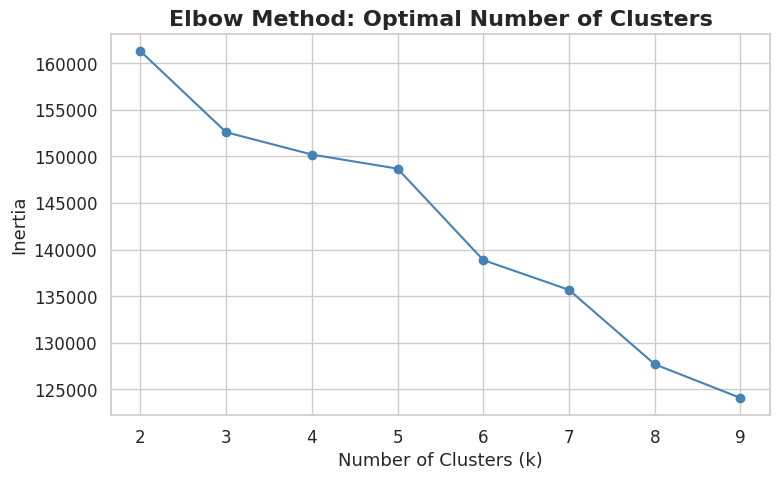

In [31]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned dataset (assuming preprocessing is already done)
df = pd.read_csv("cleaned_formatting_data.csv")

# Just keeping numeric columns for clustering (we'll skip categoricals for now)
numeric_df = df.select_dtypes(include=['int64', 'float64']).copy()
numeric_df.fillna(numeric_df.mean(), inplace=True)  # Filling any leftover missing values

# Standardizing the data to make clustering meaningful
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)

# Let's try different k values and see where the elbow is
inertia = []
k_range = range(2, 10)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

# Plotting the elbow curve to decide best k visually
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', linestyle='-', color='steelblue')
plt.title("Elbow Method: Optimal Number of Clusters", fontsize=16, fontweight='bold')
plt.xlabel("Number of Clusters (k)", fontsize=13)
plt.ylabel("Inertia", fontsize=13)
plt.xticks(k_range)
plt.grid(True)
plt.tight_layout()
plt.show()

<ipython-input-32-4e99f9bcc062>:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


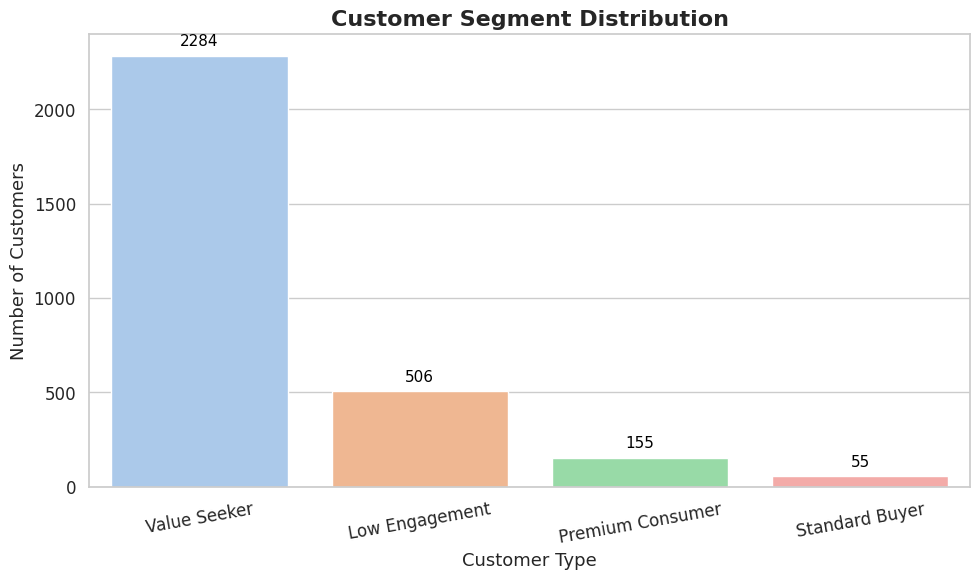

In [32]:
#applying KMeans with k=4
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_data)

# Now, let's assign meaningful labels to these clusters based on simple logic
def assign_label(row):
    try:
        if row['Avg Order Value'] > 70 and row['Loyalty Program Member'] >= 1 and row['Return_Rate'] < 10:
            return 'Premium Consumer'
        elif row['Discounted'] == 1 and row['Coupon_Code_Usage'] >= 2:
            return 'Value Seeker'
        elif row['Cart Abandoned'] >= 1 or row['Return_Rate'] >= 20:
            return 'Low Engagement'
        else:
            return 'Standard Buyer'
    except:
        return 'Standard Buyer'  # fallback in case any field is missing

df['Customer_Type'] = df.apply(assign_label, axis=1)

# Plotting how many customers fall into each segment
sns.set(style="whitegrid", font_scale=1.1)
plt.figure(figsize=(10, 6))
ax = sns.countplot(
    data=df,
    x='Customer_Type',
    palette='pastel',
    order=df['Customer_Type'].value_counts().index
)

# Adding the numbers on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=5, fontsize=11, color='black')

plt.title("Customer Segment Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Customer Type", fontsize=13)
plt.ylabel("Number of Customers", fontsize=13)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

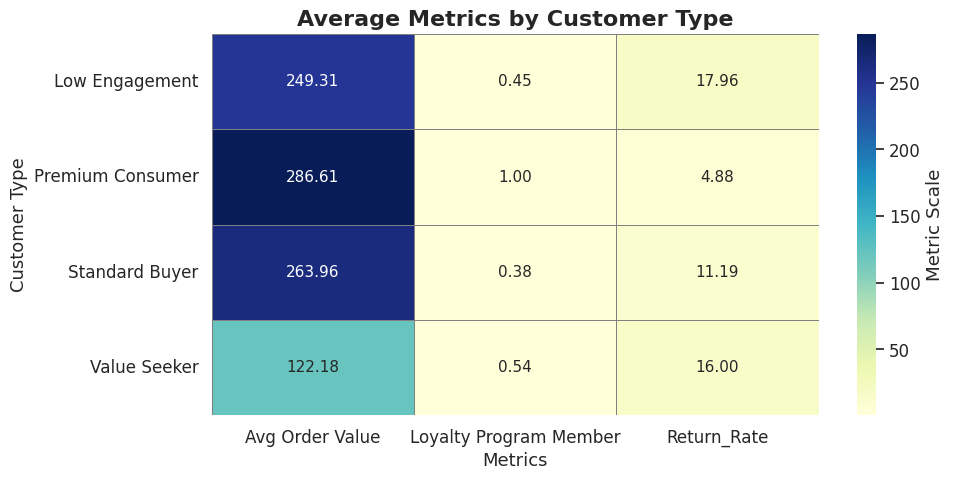

In [33]:
# average values for each segment
summary = df.groupby('Customer_Type')[['Avg Order Value', 'Loyalty Program Member', 'Return_Rate']].mean()

# Visualizing the metrics using a heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(
    summary,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.6,
    linecolor='gray',
    cbar_kws={'label': 'Metric Scale'},
    annot_kws={'fontsize': 11}
)

plt.title("Average Metrics by Customer Type", fontsize=16, fontweight='bold')
plt.xlabel("Metrics", fontsize=13)
plt.ylabel("Customer Type", fontsize=13)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()